# TP4 :  Low-budget  Learning

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data are available for training, say 

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. Hence we are not in the context of classical well-organized benchmark datasets.

To make your life easier, you also get a validation set $\mathcal{X}_{\text{val}}$ representative of the test set, but you cannot use it for training. You can only use it to select the best model and hyperparameters.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. We also assume that we have a limited computational budget (e.g., limited GPU access).


In this practical, we will use the `resnet10` architecture. 

# QUESTIONS

## Grading

You will need to provide 4 files : 
1. This Notebook
2. `utils.py`
3. `drawing_lora.png`
4. `cutmix.png`

Some of the code will be automatically graded so please follow the instructions carefully.

You will also need to participate in a competition on https://www.codabench.org to get your model evaluated on the hidden test set (the link to the competition will be provided on the course forum). Before submitting anything make sure to read the instructions on the competition page. The evaluation metric is the accuracy. However, *this is not a competition* as it is not necessary to get the best score to get a good grade. If you get a good score, and follow the instructions, you will get a good grade.

`utils.py` will be imported during the testing phase so please make sure:
- it does not execute any code when imported
- it does not depend on any module that is not standard (e.g., not `torch`, `torchvision`, `numpy`, etc.)


General instructions:
- Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).
- For each question that involves training a model:
    - Give the number of trained parameters.
    - You must provide the training curves (train & validation accuracy/loss vs epochs) in the notebook.
    - You must explain the choices you made (hyperparameters, etc). (A short justification is enough. For instance, "I used default hyperparameters." does not need further explanation. Or "I tried (0.1,0.01,0.001) and picked 0.01 because it gave the best validation accuracy." is enough.)
    - You must comment on the accuracy obtained.
- If you use a seed for reproducibility, please make sure it is a personal one using something like `hash("your_firstname_your_lastname")`.

<div class="alert alert-info">  Example of answer  </div>

In [33]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [34]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"

for macOS fix : 

In [35]:
import os

if not os.path.exists("data"):
    os.mkdir("data")

if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")

if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && curl -L -o north_dataset_train.zip "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    
    !cd data/TP4_images && curl -L -o north_dataset_test.zip "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip

In [37]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)


metric = ConfusionMatrix(task="multiclass", num_classes=2).to(device)


def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model


base_model = model_instancier()
classifier_name = "fc"


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 42
Validation dataset size: 42


## Question 1: 
>  Create `last_layer.py` to change the last layer of the resnet model so that it fits the problem.

In [38]:
from last_layer import LastLayer

setattr(base_model, classifier_name, LastLayer())
assert (
    getattr(base_model, classifier_name).out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2: 
> Provide a function `precompute_features` in `utils.py` that creates a new dataset from the features precomputed by the model.

In [ ]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix

def precompute_features(
    model: models.ResNet, dataset: torch.utils.data.Dataset, device: torch.device
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is
    the rest of the model, it is not necessary to recompute $g(x)$ at
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and
    create a new dataset
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: models.ResNet
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation

    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    features_extractor = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
    features_extractor.eval()
    all_features = []
    all_labels = []
    # iterate over the old dataset
    with torch.no_grad():
        for images, labels in dataset: 
            images = images.to(device)
            labels = torch.as_tensor(labels, device=device)
            features = features_extractor(images.unsqueeze(0))  
            all_features.append(features.squeeze(0))  
            all_labels.append(labels)
    all_features = torch.stack(all_features)  # concat the features
    all_labels = torch.stack(all_labels)
    return torch.utils.data.TensorDataset(all_features.cpu(), all_labels.cpu())


## Question 3: 
> Train the last layer of a randomly initialized resnet model.  Provide the training process in the notebook with training curve. Comment on the accuracy. 

In [40]:
from utils import precompute_features

In [41]:
base_model = model_instancier()
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

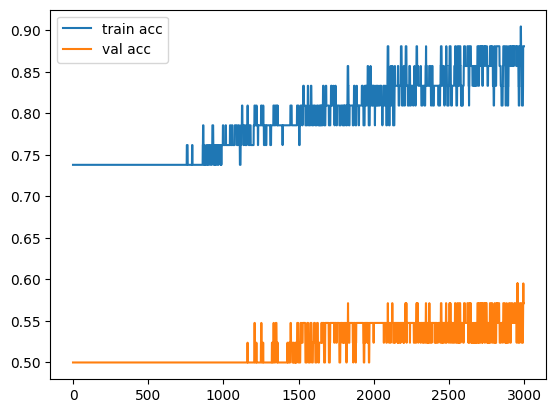

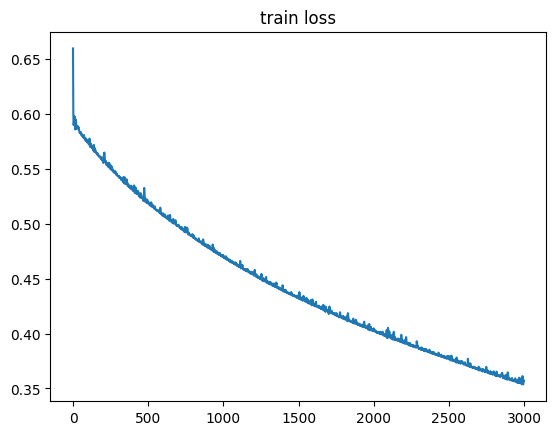

Final acc: tensor(0.5714)


In [42]:
from peft import LoraConfig, get_peft_model
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights
from torchmetrics import Accuracy
import matplotlib.pyplot as plt

# freeze everything except the last fc layer
for p in base_model.parameters():
    p.requires_grad = False
for p in base_model.fc.parameters():
    p.requires_grad = True
base_model.eval()
base_model.fc.train()

# dataloaders to batch TensorDataset 
batch_size = 32
train_loader = DataLoader(train_features_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_features_dataset, batch_size=batch_size, shuffle=False)

epochs = 3000
lr = 0.001
optimizer = torch.optim.Adam(params=base_model.fc.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

accuracy = Accuracy(task="multiclass", num_classes=2).to(device)
accuracy_val = Accuracy(task="multiclass", num_classes=2).to(device)

losses = []
accuracies = []
accuracies_val = []

for _ in range(epochs):
    base_model.fc.train()
    accuracy.reset()
    epoch_loss = 0.0

    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)
        features = features.view(features.size(0), -1)

        optimizer.zero_grad()
        outputs = base_model.fc(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * labels.size(0)
        accuracy.update(outputs, labels)

    losses.append(epoch_loss / len(train_loader.dataset))
    accuracies.append(accuracy.compute())

    # validation
    base_model.fc.eval()
    accuracy_val.reset()
    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            features = features.view(features.size(0), -1)
            outputs = base_model.fc(features)
            accuracy_val.update(outputs, labels)

    accuracies_val.append(accuracy_val.compute())

plt.plot(accuracies, label="train acc")
plt.plot(accuracies_val, label="val acc")
plt.legend()
plt.show()
plt.plot(losses)
plt.title("train loss")
plt.show()

print("Final acc:", accuracies_val[-1])


We can see that the model is overfitting, as the linear layer is not able to capture any meaningful information and therefore can't generalize. 

## Question 4:
>  Now start from a pretrained model on imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve. 

This is the first question evaluated on the codabench platform.

In [72]:
from torchvision.models import ResNet18_Weights

base_model = model_instancier(weights=ResNet18_Weights.IMAGENET1K_V1)
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [73]:
train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

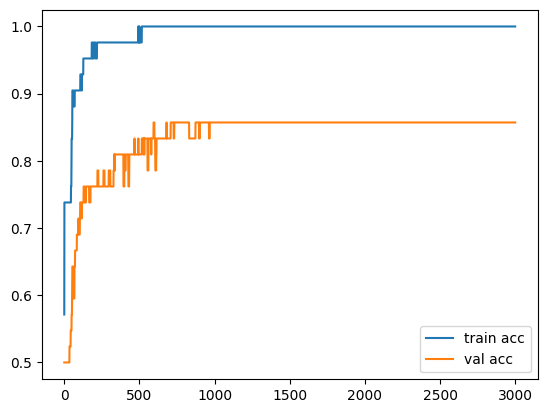

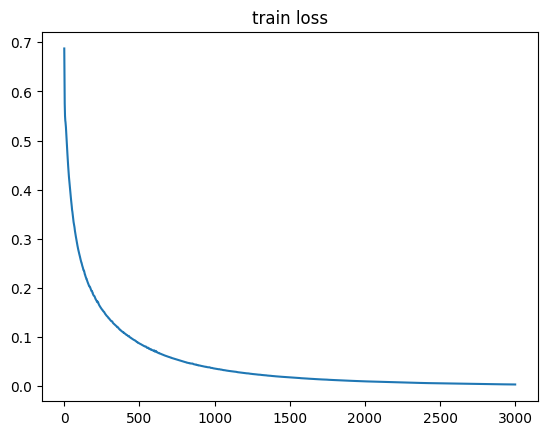

Final acc: tensor(0.8571)


In [74]:
from peft import LoraConfig, get_peft_model
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights
from torchmetrics import Accuracy
import matplotlib.pyplot as plt

# freeze everything except the last fc layer
for p in base_model.parameters():
    p.requires_grad = False
for p in base_model.fc.parameters():
    p.requires_grad = True
base_model.eval()
base_model.fc.train()

# dataloaders to batch TensorDataset 
batch_size = 32
train_loader = DataLoader(train_features_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_features_dataset, batch_size=batch_size, shuffle=False)

epochs = 3000
lr = 0.001
optimizer = torch.optim.Adam(params=base_model.fc.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

accuracy = Accuracy(task="multiclass", num_classes=2).to(device)
accuracy_val = Accuracy(task="multiclass", num_classes=2).to(device)

losses = []
accuracies = []
accuracies_val = []

for _ in range(epochs):
    base_model.fc.train()
    accuracy.reset()
    epoch_loss = 0.0

    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)
        features = features.view(features.size(0), -1)

        optimizer.zero_grad()
        outputs = base_model.fc(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * labels.size(0)
        accuracy.update(outputs, labels)

    losses.append(epoch_loss / len(train_loader.dataset))
    accuracies.append(accuracy.compute())

    # validation
    base_model.fc.eval()
    accuracy_val.reset()
    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            features = features.view(features.size(0), -1)
            outputs = base_model.fc(features)
            accuracy_val.update(outputs, labels)

    accuracies_val.append(accuracy_val.compute())

plt.plot(accuracies, label="train acc")
plt.plot(accuracies_val, label="val acc")
plt.legend()
plt.show()
plt.plot(losses)
plt.title("train loss")
plt.show()

print("Final acc:", accuracies_val[-1])


<div class="alert alert-info">  You should achieve >80% accuracy on the val set.  </div>

### Save your model

In [75]:
# Save the last layer weights for grading on codabench
torch.save(getattr(base_model, classifier_name).state_dict(), "last_layer_finetune.pth")

### Check that you can load your model

In [76]:
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(
    torch.load("last_layer_finetune.pth", weights_only=True, map_location=device)
)
setattr(model, classifier_name, fc)
model.eval()
pass

## Question 5:
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  ( We are perfectly fine if you use external library for this question only ) 

Intermediate question : Describe LoRA and the difference with LoRA for Convolutions in this paper : https://arxiv.org/pdf/2401.17868  in a few lines  (you do not have to implement ConvLora)"Describe LoRA. There are different ways of implementing LoRa for convolutions. You can choose your preferred one. Explain the version of LoRa you used, provide a drawing of the process in the drawing_lora.png file. (Hint: you can obtain a small rank convolution by combining a convolution and a 1x1 convolution. One of the two goes from a higher number of channels to a lower number of channels and the other one restores the number of channels.)"

Difference between LoRA and LoRA for convolutions : 

trainable params: 208,896 || all params: 5,115,714 || trainable%: 4.0834


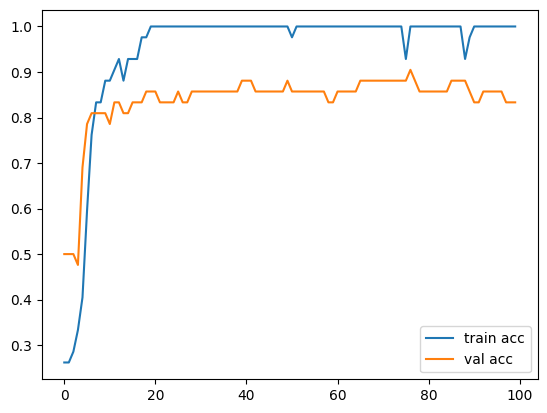

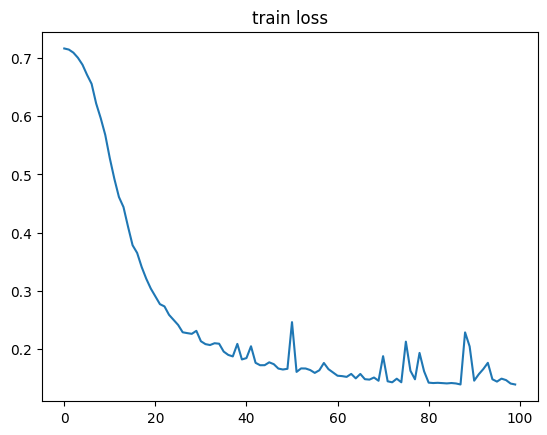

Final acc: 0.8333333134651184


In [54]:
# we need to add LoRA here : 
# do we need to use LoRA on the whole model, or only on the fc layer ? i suppose on the whole 
from peft import LoraConfig, get_peft_model

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# datasets (images directly)
train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transform
)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# reload a new model 
base_model = model_instancier(weights=ResNet18_Weights.IMAGENET1K_V1)
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)
# freeze everything, except fc, as we only train LoRA on backbone
for p in base_model.parameters():
    p.requires_grad = False
for p in model.base_model.fc.parameters():
    p.requires_grad = True

base_model.eval()
base_model.fc.train()
# initialize LazyLinear
_ = base_model.fc(torch.zeros(1, 512, device=device))

# LoRA - only on layer3, layer4 and fc, to avoid overfitting
target_modules = [
    name for name, module in base_model.named_modules()
    if (
        ("layer3" in name or "layer4" in name)
        and isinstance(module, (nn.Conv2d, nn.Linear))
    )
]

config = LoraConfig(
    r=16,
    lora_alpha=8,
    target_modules=target_modules,
    lora_dropout=0.1,
    bias="none",
)

model = get_peft_model(base_model, config) 
model.print_trainable_parameters()
model = model.to(device)


epochs = 100
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

accuracy = Accuracy(task="multiclass", num_classes=2).to(device)
accuracy_val = Accuracy(task="multiclass", num_classes=2).to(device)

losses = []
accuracies = []
accuracies_val = []

for _ in range(epochs):
    model.train()
    accuracy.reset()
    epoch_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * labels.size(0)
        accuracy.update(outputs, labels)

    losses.append(epoch_loss / len(train_loader.dataset))
    accuracies.append(accuracy.compute().item())

    # validation
    model.eval()
    accuracy_val.reset()
    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            accuracy_val.update(outputs, labels)

    accuracies_val.append(accuracy_val.compute().item())

plt.plot(accuracies, label="train acc")
plt.plot(accuracies_val, label="val acc")
plt.legend()
plt.show()
plt.plot(losses)
plt.title("train loss")
plt.show()

print("Final acc:", accuracies_val[-1])

## Question 6:
> Let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them into your training pipeline.

Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing. 

You can find many other data augmentation techniques here: https://docs.pytorch.org/vision/0.15/transforms.html

This is the second question evaluated on the codabench platform.

CutMIX : it is a data augmentation strategy, consisting of replacing a randomly chosen patch of an image $x_1$ by the corresponding patch from another patch $x_2$, creating an augmented training input, whose label is a proportionnal linear combination of the ones of $x_1$ and $x_2$, (noted $y_1$ and $y_2$), ie $label=\lambda y_1+(1- \lambda y_2)$. 

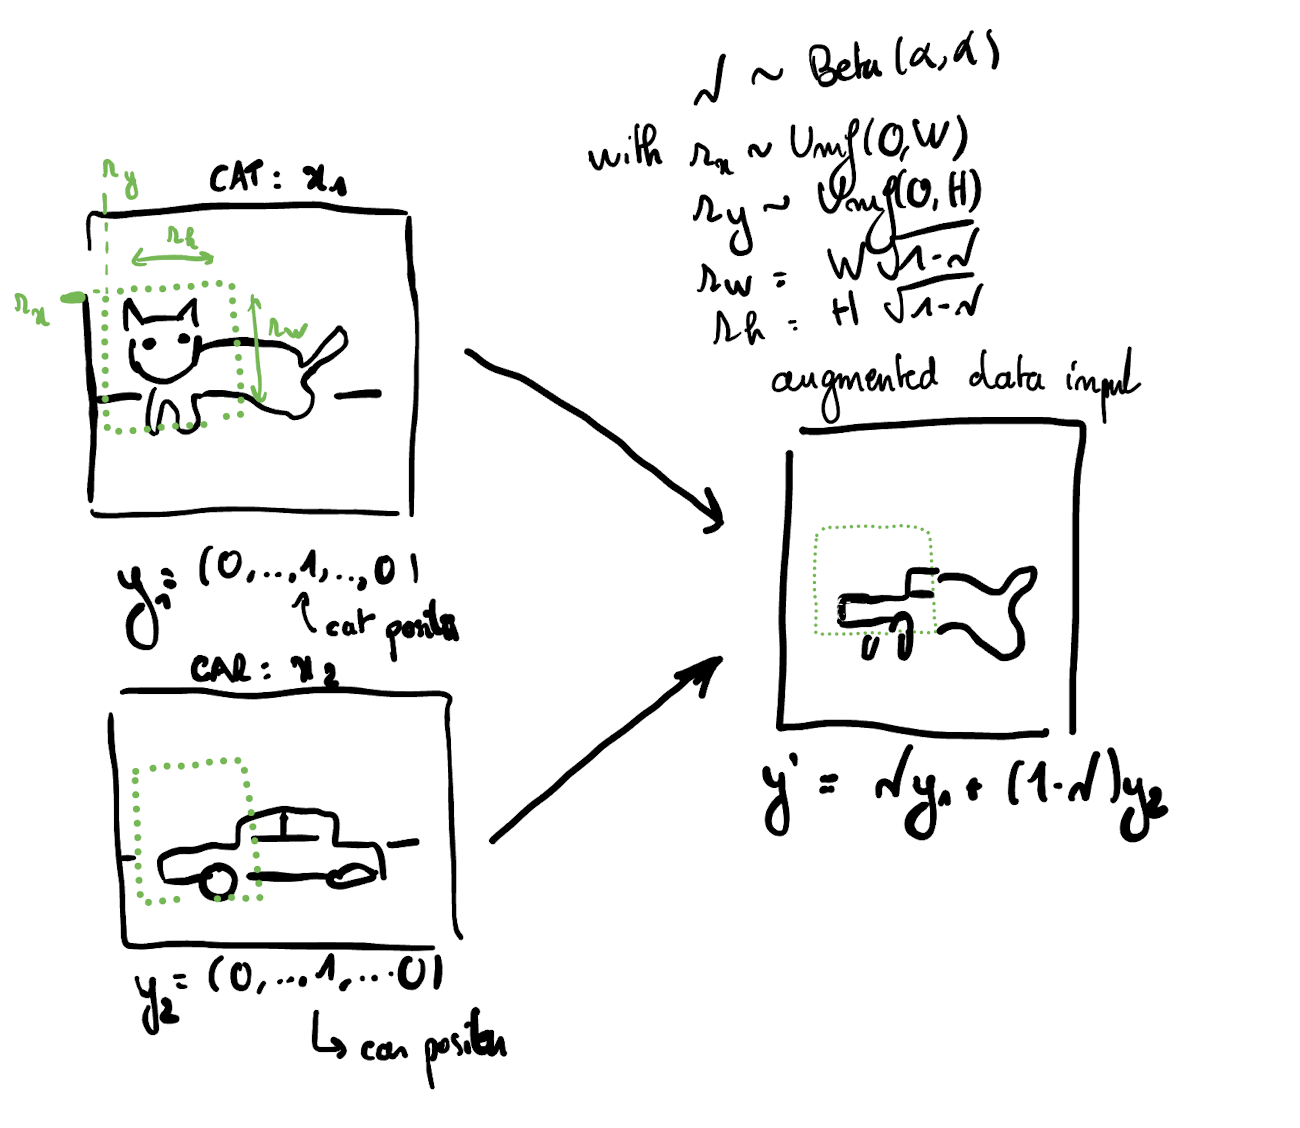

It permits to introduce a regularization effect (as the model can less overfit certain part of an image, that are often randomly replaced) as Cutout, while still being efficient, as every pixel is informative, which was not the case with Cutout that removed the information. 

Mixing the labels works as forcing the model to behave linearly between samples, as a linear combination of the inputs should correspond to a mixture of their labels, forcing smoother decision boundary, and more intuitively forcing the model to understand that this image is "a mix between a car and a cat". 

trainable params: 217,120 || all params: 5,123,938 || trainable%: 4.2374


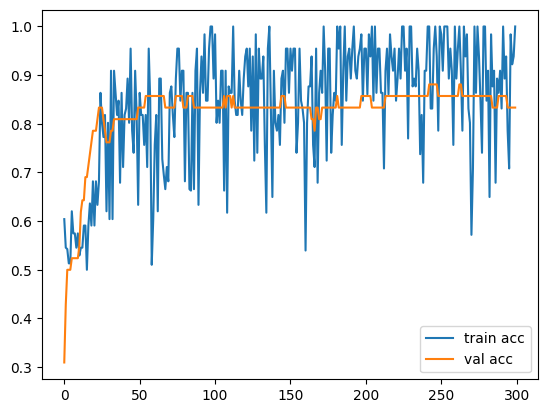

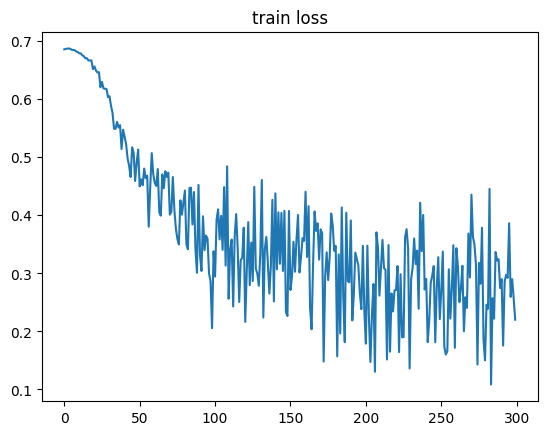

Final val acc: 0.8333333730697632


In [83]:
import torchvision.transforms.v2 as T
from torchvision import datasets
from torch.utils.data import DataLoader
from torch.utils.data.dataloader import default_collate
from torchmetrics.classification import MulticlassAccuracy
import numpy as np
import torch
import torch.nn.functional as F

# transforms

train_transforms = T.Compose([
    #T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(90),
    T.ColorJitter(0.1,0.1,0.1,0.02),
    T.ToImage(),
    T.ConvertImageDtype(torch.float32),
])

val_transforms = T.Compose([
    #T.Resize(256),
    #T.CenterCrop(224),
    T.ToImage(),
    T.ConvertImageDtype(torch.float32),
])


NUM_CLASSES = 2

cutmix = T.CutMix(num_classes=NUM_CLASSES)
#mixup = T.MixUp(num_classes=NUM_CLASSES)
#cutmix_or_mixup = T.RandomChoice([cutmix, mixup])

# build datasets 

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=val_transforms
)

# dataloaders

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# model 

# reload a new model 
base_model = model_instancier(weights=ResNet18_Weights.IMAGENET1K_V1)
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)
# freeze everything, as we only train LoRA 
for p in base_model.parameters():
    p.requires_grad = False

base_model.eval()
base_model.fc.train()
# initialize LazyLinear
_ = base_model.fc(torch.zeros(1, 512, device=device))

# LoRA
target_modules = [
    name for name, module in base_model.named_modules()
    if (
        ("layer3" in name or "layer4" in name or "fc" in name)
        and isinstance(module, (nn.Conv2d, nn.Linear))
    )
]
config = LoraConfig(
    r=16,
    lora_alpha=8,
    target_modules=target_modules,
    lora_dropout=0.1,
    bias="none",
)

model = get_peft_model(base_model, config) 
model.print_trainable_parameters()
model = model.to(device)

# training loop, as before 

epochs = 300
lr = 0.0003

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

criterion = nn.BCEWithLogitsLoss()

acc_metric = MulticlassAccuracy(num_classes=2).to(device)
acc_metric_val = MulticlassAccuracy(num_classes=2).to(device)

losses = []
accuracies = []
accuracies_val = []

for _ in range(epochs):

    model.train()
    acc_metric.reset()
    epoch_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        # apply cutmix or Mixup 
        images, labels = cutmix(images, labels)
        hard_labels = labels.argmax(dim=1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * labels.size(0)
        acc_metric.update(outputs, hard_labels)

    losses.append(epoch_loss / len(train_loader.dataset))
    accuracies.append(acc_metric.compute().item())

    # validation
    model.eval()
    acc_metric_val.reset()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            acc_metric_val.update(outputs, labels)

    accuracies_val.append(acc_metric_val.compute().item())

# plots

plt.plot(accuracies, label="train acc")
plt.plot(accuracies_val, label="val acc")
plt.legend()
plt.show()
plt.plot(losses)
plt.title("train loss")
plt.show()
print("Final val acc:", accuracies_val[-1])

### Save your model

In [84]:
# Merge LoRA weights back into the base model
merged_model = model.merge_and_unload()  # TODO: Merge LoRA weights back into the base model
assert isinstance(merged_model, models.ResNet)

torch.save(merged_model.state_dict(), "final_model.pth")

### Check that you can load your model

In [85]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel

<div class="alert alert-info">  With LoRA and Data Augmentation you should be able to improve your model's performance compared to only fine-tuning the last layer. </div>

# submission testing 

In [80]:
from last_layer import LastLayer

val_transforms = T.Compose([
    T.ToImage(),
    T.ConvertImageDtype(torch.float32),
])


val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=val_transforms
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(torch.load("last_layer_finetune.pth", weights_only=True, map_location=device))
setattr(model, classifier_name, fc)
model.eval()
model.eval()
acc_metric_val.reset()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        acc_metric_val.update(outputs, labels)

print(acc_metric_val.compute().item())


0.5952380895614624


In [86]:
from last_layer import LastLayer

val_transforms = T.Compose([
    T.ToImage(),
    T.ConvertImageDtype(torch.float32),
])


val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=val_transforms
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()
acc_metric_val.reset()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        acc_metric_val.update(outputs, labels)

print(acc_metric_val.compute().item())


0.8333333730697632


# Some advice

In our experiments, we only used SGD and a laptop GPU. We recommend not hesitating to use a large number of epochs (e.g., 100, 200, etc.). We did not use any learning rate scheduler but you can try if you want. Many data augmentation techniques exist, you can try them and see if they improve your performance. You can also try to combine them. For instance, you can try to combine CutMix with some geometric transformations (e.g., random crop, random horizontal flip, etc.).

The improvement from LoRA and data augmentation is quite hard to see on the small validation set. If you get even a small improvement on the validation set, it is likely that you will get a better score on the test set, except if you overfit the validation set. With an honest improvement on the validation set, you should be able to get a good grade.